# 01 - EDA e Tratamento de Dados

**Projeto Final — MBA BI Master (PUC-Rio)**
Previsão de Vendas com Machine Learning

**Base:** Rossmann Store Sales (Kaggle) — 1.115 lojas, vendas diárias entre 2013 e 2015.

**Objetivo deste notebook:** entender a estrutura dos dados, identificar problemas de
qualidade e gerar uma base limpa e enriquecida para a etapa de modelagem (notebook 02).

## Bloco 1 — Setup e carga dos dados

In [77]:
# Bibliotecas básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Bibliotecas carregadas.')
print('Versão do pandas:', pd.__version__)

Bibliotecas carregadas.
Versão do pandas: 2.2.3


In [40]:
import gdown

# IDs dos arquivos no Google Drive.
# O ID está no link de compartilhamento:
#   https://drive.google.com/file/d/ESTE_PEDACO_AQUI/view?usp=sharing
ID_TRAIN = '1H2UPaKBIiNt0KTjLvBmtYmy5dtY0LVI3'
ID_STORE = '12TA3jAWjb892__7m5U3Lmc5lmVd-pX0-'

gdown.download(id=ID_TRAIN, output='train.csv', quiet=False)
gdown.download(id=ID_STORE, output='store.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1H2UPaKBIiNt0KTjLvBmtYmy5dtY0LVI3
To: /content/train.csv
100%|██████████| 38.1M/38.1M [00:00<00:00, 69.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=12TA3jAWjb892__7m5U3Lmc5lmVd-pX0-
To: /content/store.csv
100%|██████████| 45.0k/45.0k [00:00<00:00, 50.0MB/s]


'store.csv'

In [41]:
# Conferência rápida: os arquivos chegaram inteiros?
# Se o compartilhamento do Drive não estiver liberado, o gdown baixa uma página
# HTML de erro com poucos KB em vez do CSV — e o problema só apareceria na leitura.
!ls -lh train.csv store.csv

-rw-r--r-- 1 root root 44K Jun 28 14:17 store.csv
-rw-r--r-- 1 root root 37M Jun 28 14:18 train.csv


In [42]:
# ATENÇÃO: a coluna StateHoliday mistura o número 0 e a letra '0' (texto).
# Se deixarmos o pandas adivinhar o tipo, ela vira uma coluna de tipo misto
# e quebra qualquer agrupamento depois. Por isso forçamos a leitura como texto.
train = pd.read_csv('train.csv', parse_dates=['Date'], dtype={'StateHoliday': str})
store = pd.read_csv('store.csv')

print('train:', train.shape)
print('store:', store.shape)
train.head()

train: (1017209, 9)
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [43]:
# Estrutura da tabela de lojas (características fixas de cada loja)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Bloco 2 — Diagnóstico inicial

Antes de qualquer análise, precisamos saber o que temos em mãos: período coberto,
quantidade de lojas, tipos de dados, valores ausentes e duplicatas.

In [44]:
print('Período:', train['Date'].min().date(), 'até', train['Date'].max().date())
print('Nº de lojas:', train['Store'].nunique())
print('Nº de datas distintas:', train['Date'].nunique())
print()
train.info()

Período: 2013-01-01 até 2015-07-31
Nº de lojas: 1115
Nº de datas distintas: 942

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [45]:
print('--- Nulos em train ---')
print(train.isna().sum())

print('\n--- Nulos em store ---')
print(store.isna().sum())

print('\nDuplicatas (mesma loja + mesma data):',
      train.duplicated(subset=['Store', 'Date']).sum())

--- Nulos em train ---
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

--- Nulos em store ---
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Duplicatas (mesma loja + mesma data): 0


In [46]:
fechado = (train['Open'] == 0).sum()
aberto_sem_venda = ((train['Open'] == 1) & (train['Sales'] == 0)).sum()

print(f'Dias com loja fechada:            {fechado:,} ({fechado/len(train):.1%} da base)')
print(f'Dias com loja aberta e venda 0:   {aberto_sem_venda:,}')
print(f'Venda média (apenas loja aberta): {train.loc[train["Open"]==1, "Sales"].mean():,.0f}')

Dias com loja fechada:            172,817 (17.0% da base)
Dias com loja aberta e venda 0:   54
Venda média (apenas loja aberta): 6,956


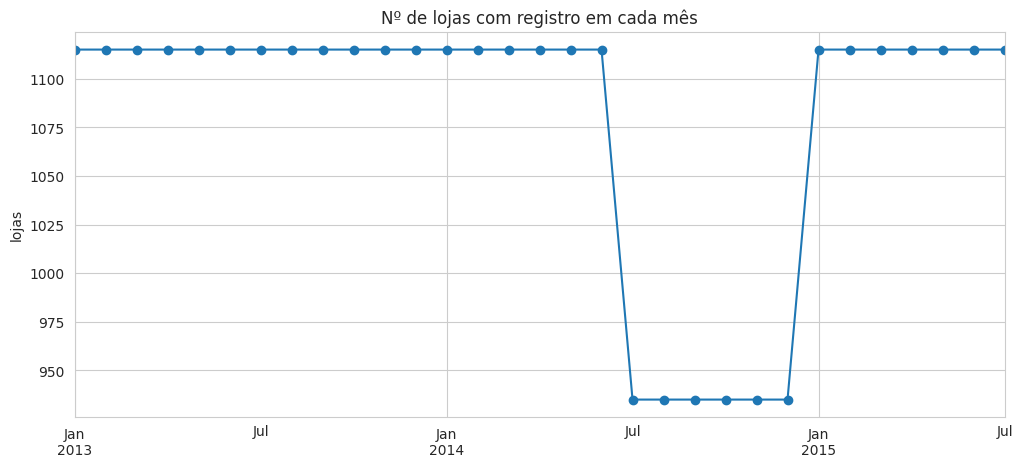

Date
2013-01    1115
2013-02    1115
2013-03    1115
2013-04    1115
2013-05    1115
2013-06    1115
2013-07    1115
2013-08    1115
2013-09    1115
2013-10    1115
2013-11    1115
2013-12    1115
2014-01    1115
2014-02    1115
2014-03    1115
2014-04    1115
2014-05    1115
2014-06    1115
2014-07     935
2014-08     935
2014-09     935
2014-10     935
2014-11     935
2014-12     935
2015-01    1115
2015-02    1115
2015-03    1115
2015-04    1115
2015-05    1115
2015-06    1115
2015-07    1115
Freq: M, Name: Store, dtype: int64


In [47]:
# Quantas lojas têm registro em cada mês?
lojas_por_mes = train.groupby(train['Date'].dt.to_period('M'))['Store'].nunique()

lojas_por_mes.plot(marker='o', title='Nº de lojas com registro em cada mês')
plt.ylabel('lojas')
plt.xlabel('')
plt.show()

print(lojas_por_mes)

> **Achado importante:** o painel **não é balanceado**. Cerca de 180 lojas desaparecem
> da base entre meados e o fim de 2014 (fechamento para reforma). Qualquer série
> agregada (soma de vendas por dia) vai mostrar uma queda artificial nesse período,
> que **não é queda de demanda**. Por isso, nas análises temporais abaixo usamos a
> **venda média por loja aberta**, e não a soma.

In [48]:
# Identificando as lojas com buraco na série
dias_por_loja = train.groupby('Store')['Date'].count()
max_dias = dias_por_loja.max()

lojas_com_gap = dias_por_loja[dias_por_loja < max_dias].index.tolist()

print(f'Nº máximo de dias por loja: {max_dias}')
print(f'Lojas com série incompleta: {len(lojas_com_gap)}')
print(f'Exemplo de lojas afetadas: {lojas_com_gap[:10]}')

Nº máximo de dias por loja: 942
Lojas com série incompleta: 181
Exemplo de lojas afetadas: [13, 20, 22, 32, 36, 41, 46, 51, 52, 58]


## Bloco 3 — Análise da variável alvo (`Sales`)

In [49]:
# Estatísticas apenas dos dias em que a loja estava aberta
vendas_abertas = train.loc[train['Open'] == 1, 'Sales']
vendas_abertas.describe()

,Sales
count,844392.000000
mean,6955.514291
std,3104.214680
min,0.000000
25%,4859.000000
50%,6369.000000
75%,8360.000000
max,41551.000000


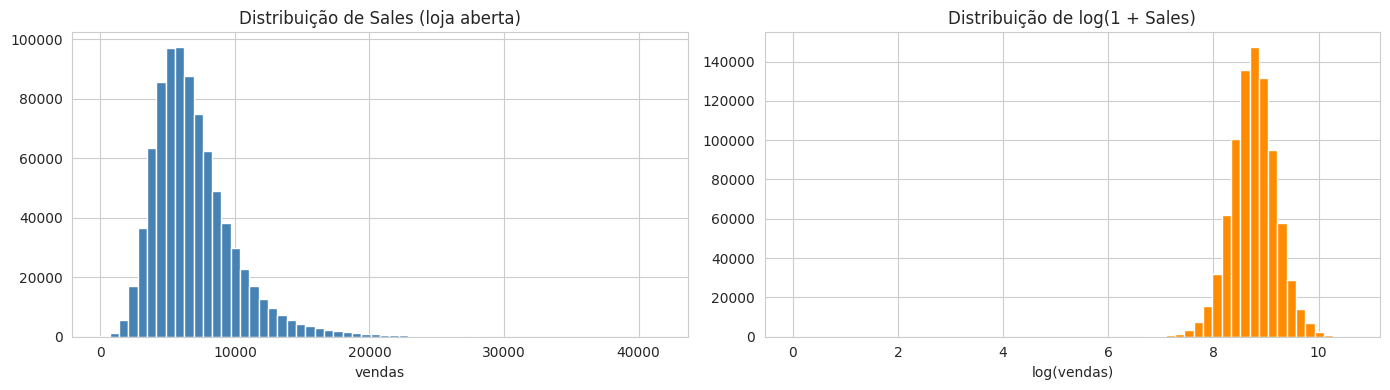

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição original: assimétrica à direita (cauda longa)
axes[0].hist(vendas_abertas, bins=60, color='steelblue')
axes[0].set_title('Distribuição de Sales (loja aberta)')
axes[0].set_xlabel('vendas')

# Distribuição em escala log: fica próxima de uma normal
axes[1].hist(np.log1p(vendas_abertas), bins=60, color='darkorange')
axes[1].set_title('Distribuição de log(1 + Sales)')
axes[1].set_xlabel('log(vendas)')

plt.tight_layout()
plt.show()

A distribuição original é assimétrica à direita. Aplicar `log1p` deixa a variável mais
simétrica — isso costuma ajudar modelos baseados em erro quadrático. É uma decisão
que testaremos no notebook de modelagem (treinar em `log(Sales)` e reverter a previsão
com `expm1`).

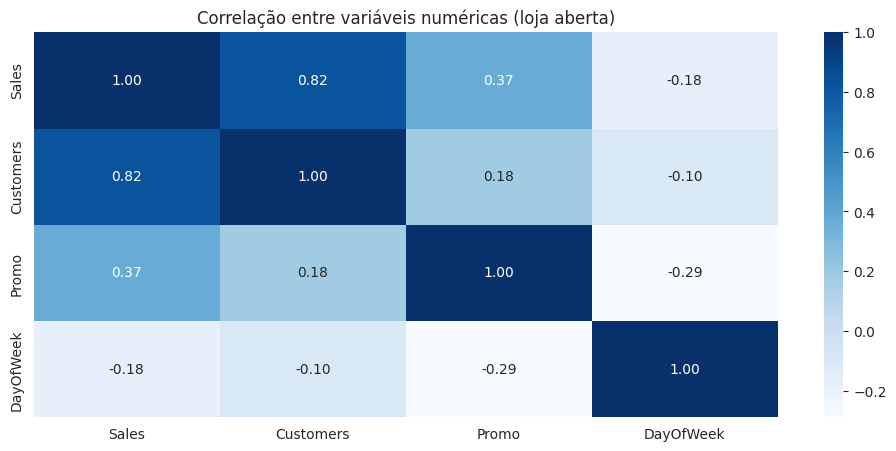

In [51]:
# Quanto Customers explica de Sales?
corr = train.loc[train['Open'] == 1, ['Sales', 'Customers', 'Promo', 'DayOfWeek']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlação entre variáveis numéricas (loja aberta)')
plt.show()

> **Cuidado com vazamento de dados (data leakage):** `Customers` é a variável mais
> correlacionada com `Sales`, mas **não está disponível no momento da previsão** —
> não sabemos quantos clientes entrarão na loja amanhã. Usar essa coluna como preditora
> geraria um modelo com desempenho excelente no papel e inútil na prática.
> **Decisão: descartar `Customers` na etapa de tratamento** (registrada no README).

## Bloco 4 — Padrões temporais

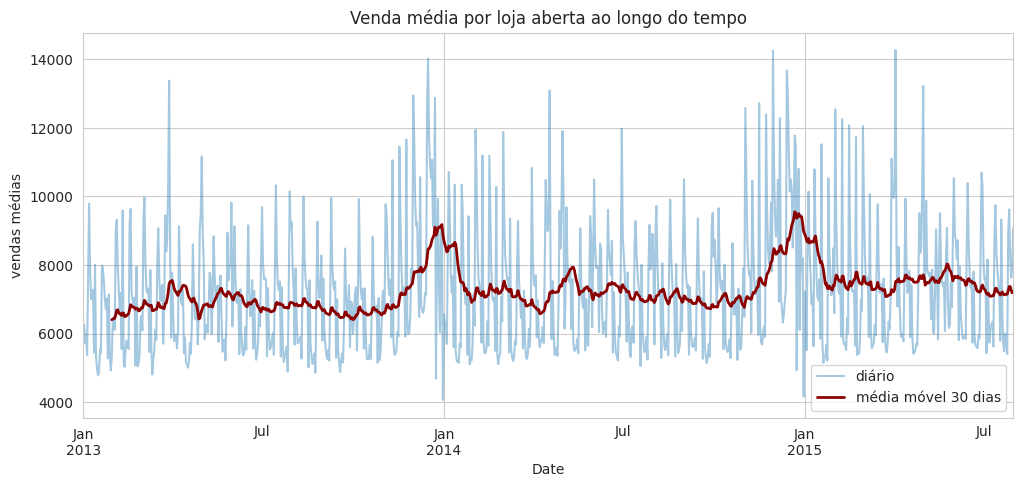

In [52]:
# Venda média por loja aberta, por dia (evita o efeito do painel desbalanceado)
serie_diaria = (train[train['Open'] == 1]
                .groupby('Date')['Sales']
                .mean())

serie_diaria.plot(alpha=0.4, label='diário')
serie_diaria.rolling(30).mean().plot(color='darkred', linewidth=2, label='média móvel 30 dias')
plt.title('Venda média por loja aberta ao longo do tempo')
plt.ylabel('vendas médias')
plt.legend()
plt.show()

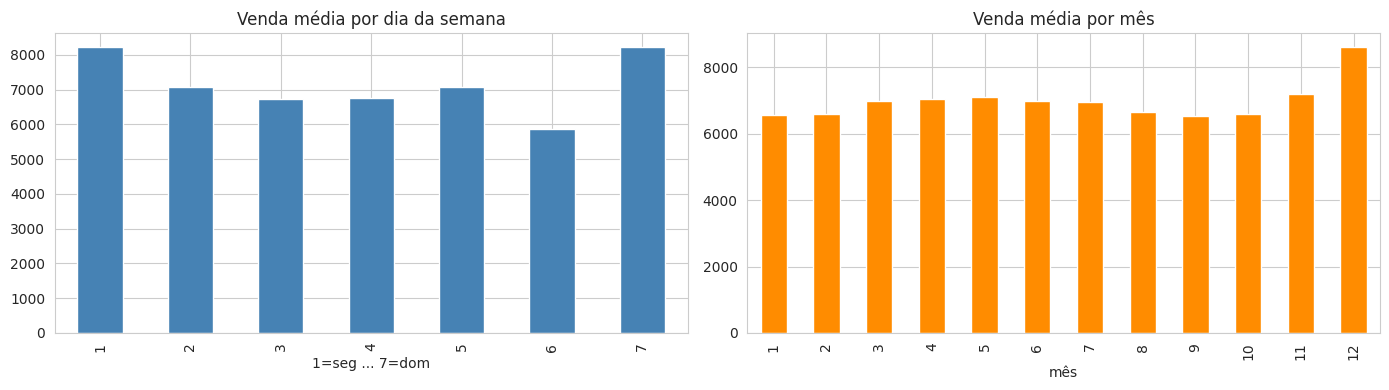

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Dia da semana (1 = segunda ... 7 = domingo)
(train[train['Open'] == 1]
 .groupby('DayOfWeek')['Sales'].mean()
 .plot(kind='bar', ax=axes[0], color='steelblue'))
axes[0].set_title('Venda média por dia da semana')
axes[0].set_xlabel('1=seg ... 7=dom')

# Mês do ano
(train[train['Open'] == 1]
 .groupby(train['Date'].dt.month)['Sales'].mean()
 .plot(kind='bar', ax=axes[1], color='darkorange'))
axes[1].set_title('Venda média por mês')
axes[1].set_xlabel('mês')

plt.tight_layout()
plt.show()

In [54]:
# Quantas lojas abrem aos domingos? (explica a média do dia 7)
domingos = train[train['DayOfWeek'] == 7]
print('Lojas que já abriram em algum domingo:', domingos.loc[domingos['Open'] == 1, 'Store'].nunique())
print('Proporção de domingos com loja aberta:', f"{(domingos['Open'] == 1).mean():.2%}")

Lojas que já abriram em algum domingo: 33
Proporção de domingos com loja aberta: 2.48%


## Bloco 5 — Efeito de promoções e feriados

In [55]:
abertas = train[train['Open'] == 1]

print('--- Venda média com e sem promoção ---')
print(abertas.groupby('Promo')['Sales'].mean().round(0))
lift = abertas.groupby('Promo')['Sales'].mean()
print(f'\nLift da promoção: {(lift[1]/lift[0] - 1):.1%}')

--- Venda média com e sem promoção ---
Promo
0    5929.0
1    8228.0
Name: Sales, dtype: float64

Lift da promoção: 38.8%


In [56]:
# StateHoliday: 'a' = feriado público, 'b' = Páscoa, 'c' = Natal, '0' = dia normal
print('--- Frequência de StateHoliday (base completa) ---')
print(train['StateHoliday'].value_counts())

print('\n--- Venda média por tipo de feriado (apenas loja aberta) ---')
print(abertas.groupby('StateHoliday')['Sales'].mean().round(0))

--- Frequência de StateHoliday (base completa) ---
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

--- Venda média por tipo de feriado (apenas loja aberta) ---
StateHoliday
0    6954.0
a    8487.0
b    9888.0
c    9744.0
Name: Sales, dtype: float64


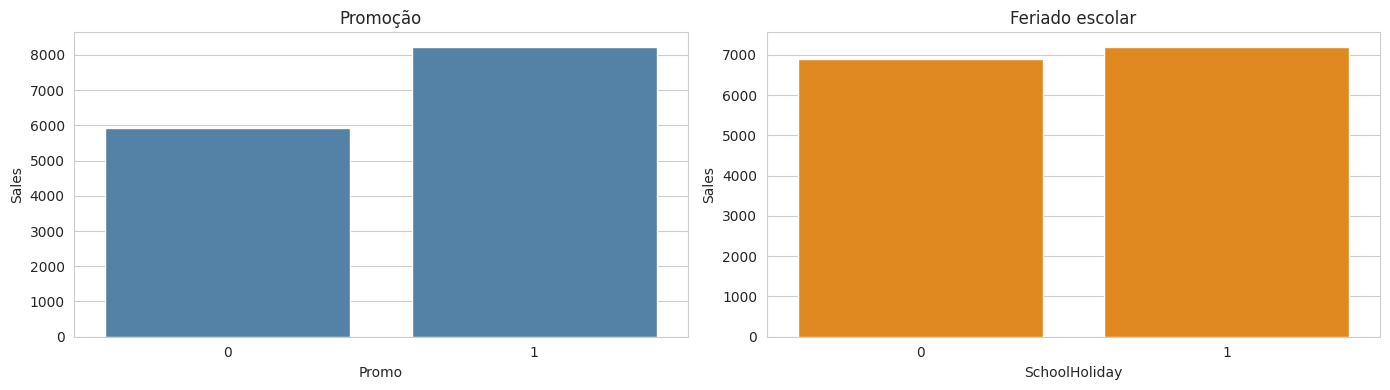

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=abertas, x='Promo', y='Sales', ax=axes[0], errorbar=None, color='steelblue')
axes[0].set_title('Promoção')

sns.barplot(data=abertas, x='SchoolHoliday', y='Sales', ax=axes[1], errorbar=None, color='darkorange')
axes[1].set_title('Feriado escolar')

plt.tight_layout()
plt.show()

## Bloco 6 — Características das lojas

Agora juntamos `train` com `store.csv`, que traz atributos fixos de cada loja
(tipo, sortimento, concorrência e participação no programa Promo2).

In [58]:
df = train.merge(store, on='Store', how='left')

print('Base combinada:', df.shape)
print('Colunas:', list(df.columns))

Base combinada: (1017209, 18)
Colunas: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


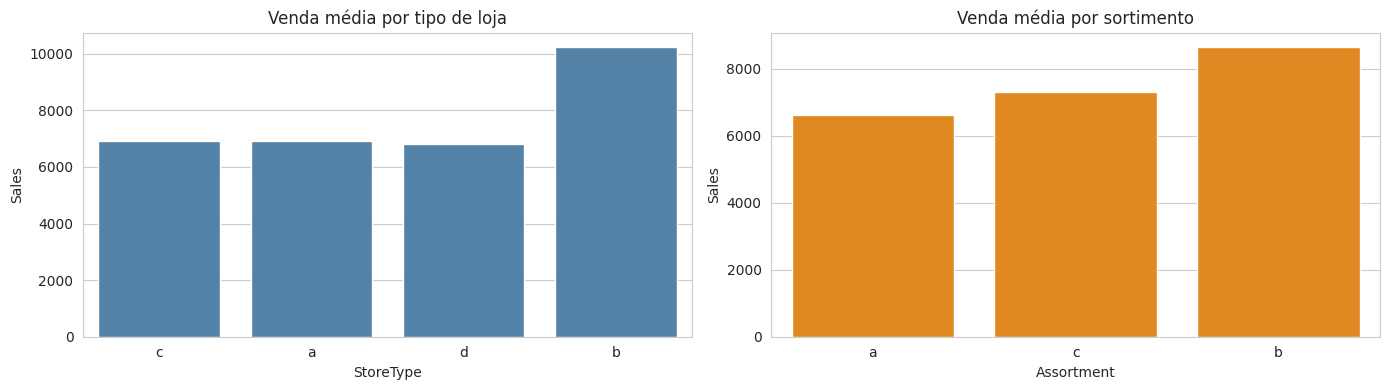

StoreType
a    457077
d    258774
c    112978
b     15563
Name: count, dtype: int64


In [59]:
abertas_df = df[df['Open'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# StoreType: a, b, c, d — modelos de loja
sns.barplot(data=abertas_df, x='StoreType', y='Sales', ax=axes[0], errorbar=None, color='steelblue')
axes[0].set_title('Venda média por tipo de loja')

# Assortment: a = básico, b = extra, c = estendido
sns.barplot(data=abertas_df, x='Assortment', y='Sales', ax=axes[1], errorbar=None, color='darkorange')
axes[1].set_title('Venda média por sortimento')

plt.tight_layout()
plt.show()

print(abertas_df['StoreType'].value_counts())

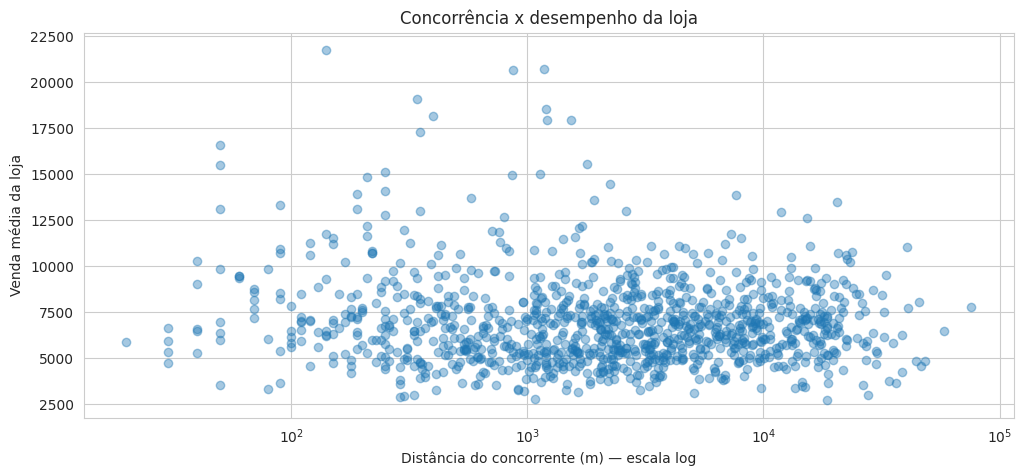

Correlação (log da distância x venda média): -0.105


In [60]:
# Distância até o concorrente mais próximo (em metros)
media_loja = abertas_df.groupby('Store').agg(
    venda_media=('Sales', 'mean'),
    dist_concorrente=('CompetitionDistance', 'first')
).dropna()

plt.scatter(media_loja['dist_concorrente'], media_loja['venda_media'], alpha=0.4)
plt.xscale('log')
plt.xlabel('Distância do concorrente (m) — escala log')
plt.ylabel('Venda média da loja')
plt.title('Concorrência x desempenho da loja')
plt.show()

print('Correlação (log da distância x venda média):',
      round(np.log1p(media_loja['dist_concorrente']).corr(media_loja['venda_media']), 3))

## Bloco 7 — Tratamento dos dados

Aqui aplicamos as decisões tomadas nas análises acima. Cada passo está comentado
para facilitar a redação da seção *Modelagem* do README.

In [61]:
# Começamos de uma cópia da base combinada
dados = df.copy()
print('Linhas iniciais:', f'{len(dados):,}')

Linhas iniciais: 1,017,209


In [62]:
# PASSO 1 — Remover dias em que a loja estava fechada.
# Justificativa: a previsão para um dia fechado é zero por regra de negócio,
# não por modelo. Manter esses dias ensinaria o modelo a prever zeros.
dados = dados[dados['Open'] == 1]

# PASSO 2 — Remover dias abertos com venda zero (registros inconsistentes, poucos casos).
dados = dados[dados['Sales'] > 0]

print('Linhas após os filtros:', f'{len(dados):,}')

Linhas após os filtros: 844,338


In [63]:
# PASSO 3 — Descartar Customers (vazamento de dados: só é conhecida após a venda)
dados = dados.drop(columns=['Customers'])

# A coluna Open agora é constante (=1), então também sai
dados = dados.drop(columns=['Open'])

print('Colunas restantes:', list(dados.columns))

Colunas restantes: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [64]:
# PASSO 4 — Tratar nulos de CompetitionDistance.
# São poucas lojas sem informação. Preenchemos com a mediana e criamos uma flag,
# para o modelo saber que ali houve imputação.
dados['SemInfoConcorrente'] = dados['CompetitionDistance'].isna().astype(int)
dados['CompetitionDistance'] = dados['CompetitionDistance'].fillna(
    dados['CompetitionDistance'].median()
)

print('Nulos restantes em CompetitionDistance:', dados['CompetitionDistance'].isna().sum())

Nulos restantes em CompetitionDistance: 0


In [65]:
# PASSO 5 — Features de data
dados['Ano'] = dados['Date'].dt.year
dados['Mes'] = dados['Date'].dt.month
dados['Dia'] = dados['Date'].dt.day
dados['SemanaDoAno'] = dados['Date'].dt.isocalendar().week.astype(int)
dados['DiaDoAno'] = dados['Date'].dt.dayofyear

dados[['Date', 'Ano', 'Mes', 'Dia', 'SemanaDoAno', 'DiaDoAno']].head()

,Date,Ano,Mes,Dia,SemanaDoAno,DiaDoAno
0,2015-07-31,2015,7,31,31,212
1,2015-07-31,2015,7,31,31,212
2,2015-07-31,2015,7,31,31,212
3,2015-07-31,2015,7,31,31,212
4,2015-07-31,2015,7,31,31,212


In [66]:
# PASSO 5b — Marcar as lojas em que a data de abertura do concorrente é desconhecida.
# São ~354 lojas que TÊM CompetitionDistance preenchida (sabemos que existe
# concorrente e a que distância), mas não têm a data de abertura.
# No Passo 6 essas lojas recebem MesesConcorrente = 0. Sem esta flag, o modelo
# confundiria "concorrente abriu agora" com "não sabemos desde quando".
dados['SemDataConcorrente'] = dados['CompetitionOpenSinceYear'].isna().astype(int)

print('Lojas por situação (0 = data conhecida, 1 = data desconhecida):')
print(dados.groupby('SemDataConcorrente')['Store'].nunique())

Lojas por situação (0 = data conhecida, 1 = data desconhecida):
SemDataConcorrente
0    761
1    354
Name: Store, dtype: int64


In [67]:
# PASSO 6 — Há quantos meses o concorrente está aberto?
# Onde não há informação, usamos 0 (equivale a "sem concorrente conhecido").
dados['MesesConcorrente'] = (
    12 * (dados['Ano'] - dados['CompetitionOpenSinceYear'])
    + (dados['Mes'] - dados['CompetitionOpenSinceMonth'])
)
# Valores negativos = concorrente ainda não tinha aberto naquela data
dados['MesesConcorrente'] = dados['MesesConcorrente'].fillna(0).clip(lower=0)

print(dados['MesesConcorrente'].describe())

count    844338.000000
mean         41.953669
std          65.189972
min           0.000000
25%           0.000000
50%          16.000000
75%          73.000000
max        1386.000000
Name: MesesConcorrente, dtype: float64


In [68]:
# PASSO 7 — Há quantos meses a loja participa do programa Promo2?
dados['MesesPromo2'] = (
    12 * (dados['Ano'] - dados['Promo2SinceYear'])
    + (dados['SemanaDoAno'] - dados['Promo2SinceWeek']) / 4.0
)
dados['MesesPromo2'] = dados['MesesPromo2'].fillna(0).clip(lower=0)

# Lojas que não participam do Promo2 recebem 0
dados.loc[dados['Promo2'] == 0, 'MesesPromo2'] = 0

print(dados['MesesPromo2'].describe())

count    844338.000000
mean         13.053234
std          18.973591
min           0.000000
25%           0.000000
50%           0.000000
75%          25.000000
max          72.000000
Name: MesesPromo2, dtype: float64


In [69]:
# PASSO 8 — A data cai dentro de um mês de renovação do Promo2?
# ATENÇÃO: o dataset usa 'Sept' (e não 'Sep') para setembro.
meses_abrev = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

dados['MesAbrev'] = dados['Mes'].map(meses_abrev)
dados['PromoInterval'] = dados['PromoInterval'].fillna('')

dados['EmMesPromo2'] = [
    1 if (mes in intervalo.split(',')) and intervalo != '' else 0
    for mes, intervalo in zip(dados['MesAbrev'], dados['PromoInterval'])
]

dados = dados.drop(columns=['MesAbrev'])

print(dados['EmMesPromo2'].value_counts())

EmMesPromo2
0    699125
1    145213
Name: count, dtype: int64


In [70]:
# PASSO 9 — Marcar lojas com série incompleta (fechamento para reforma em 2014)
dados['LojaComGap'] = dados['Store'].isin(lojas_com_gap).astype(int)

print(dados.groupby('LojaComGap')['Store'].nunique())

LojaComGap
0    934
1    181
Name: Store, dtype: int64


In [71]:
# PASSO 10 — Codificar as variáveis categóricas em números.
# StoreType e Assortment não têm ordem natural, mas modelos de árvore
# (Random Forest e XGBoost) lidam bem com codificação simples por rótulo.
mapa_storetype = {'a': 0, 'b': 1, 'c': 2, 'd': 3}
mapa_assortment = {'a': 0, 'b': 1, 'c': 2}
mapa_feriado = {'0': 0, 'a': 1, 'b': 2, 'c': 3}

dados['StoreType'] = dados['StoreType'].map(mapa_storetype)
dados['Assortment'] = dados['Assortment'].map(mapa_assortment)
dados['StateHoliday'] = dados['StateHoliday'].map(mapa_feriado).fillna(0).astype(int)

dados[['StoreType', 'Assortment', 'StateHoliday']].head()

,StoreType,Assortment,StateHoliday
0,2,0,0
1,0,0,0
2,0,0,0
3,2,2,0
4,0,0,0


In [72]:
# PASSO 11 — Remover colunas que já foram transformadas em features derivadas
colunas_descartar = [
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'
]
dados = dados.drop(columns=colunas_descartar)

print('Base final:', dados.shape)
print('\nColunas:')
print(list(dados.columns))

Base final: (844338, 22)

Colunas:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'SemInfoConcorrente', 'Ano', 'Mes', 'Dia', 'SemanaDoAno', 'DiaDoAno', 'SemDataConcorrente', 'MesesConcorrente', 'MesesPromo2', 'EmMesPromo2', 'LojaComGap']


In [73]:
# VERIFICAÇÃO FINAL — nenhum nulo deve restar
print('--- Nulos por coluna ---')
print(dados.isna().sum())

print('\n--- Tipos ---')
print(dados.dtypes)

dados.head()

--- Nulos por coluna ---
Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
SemInfoConcorrente     0
Ano                    0
Mes                    0
Dia                    0
SemanaDoAno            0
DiaDoAno               0
SemDataConcorrente     0
MesesConcorrente       0
MesesPromo2            0
EmMesPromo2            0
LojaComGap             0
dtype: int64

--- Tipos ---
Store                           int64
DayOfWeek                       int64
Date                   datetime64[ns]
Sales                           int64
Promo                           int64
StateHoliday                    int64
SchoolHoliday                   int64
StoreType                       int64
Assortment                      int64
CompetitionDistance           float64
Promo2           

,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,SemInfoConcorrente,Ano,Mes,Dia,SemanaDoAno,DiaDoAno,SemDataConcorrente,MesesConcorrente,MesesPromo2,EmMesPromo2,LojaComGap
0,1,5,2015-07-31,5263,1,0,1,2,0,1270.0,0,0,2015,7,31,31,212,0,82.0,0.00,0,0
1,2,5,2015-07-31,6064,1,0,1,0,0,570.0,1,0,2015,7,31,31,212,0,92.0,64.50,1,0
2,3,5,2015-07-31,8314,1,0,1,0,0,14130.0,1,0,2015,7,31,31,212,0,103.0,52.25,1,0
3,4,5,2015-07-31,13995,1,0,1,2,2,620.0,0,0,2015,7,31,31,212,0,70.0,0.00,0,0
4,5,5,2015-07-31,4822,1,0,1,0,0,29910.0,0,0,2015,7,31,31,212,0,3.0,0.00,0,0


## Bloco 8 — Exportação da base tratada

Salvamos em formato **Parquet**: é mais rápido de ler que CSV e preserva os tipos
das colunas (inclusive a data), evitando retrabalho no notebook 02.

In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
CAMINHO = '/content/drive/MyDrive/Trabalho MBA/dados_tratados.parquet'

dados.to_parquet(CAMINHO, index=False)
print('Arquivo salvo em:', CAMINHO)
print('Dimensões:', dados.shape)

Arquivo salvo em: /content/drive/MyDrive/Trabalho MBA/dados_tratados.parquet
Dimensões: (844338, 22)


In [76]:
# Amostra em CSV, apenas para conferência visual.
# O Parquet é binário e não abre no Excel / Google Sheets; esta amostra permite
# olhar os dados no navegador. NÃO é usada na modelagem.
CAMINHO_AMOSTRA = '/content/drive/MyDrive/Trabalho MBA/amostra_para_conferir.csv'

amostra = dados.sample(2000, random_state=42).sort_values(['Store', 'Date'])
amostra.to_csv(CAMINHO_AMOSTRA, index=False)

print('Amostra salva em:', CAMINHO_AMOSTRA)
print('Linhas na amostra:', len(amostra))
amostra.head()

Amostra salva em: /content/drive/MyDrive/Trabalho MBA/amostra_para_conferir.csv
Linhas na amostra: 2000


,Store,DayOfWeek,Date,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,SemInfoConcorrente,Ano,Mes,Dia,SemanaDoAno,DiaDoAno,SemDataConcorrente,MesesConcorrente,MesesPromo2,EmMesPromo2,LojaComGap
1007177,3,3,2013-01-09,8001,1,0,0,0,0,14130.0,1,0,2013,1,9,2,9,0,73.0,21.0,1,0
601317,3,3,2014-01-08,8242,1,0,0,0,0,14130.0,1,0,2014,1,8,2,8,0,85.0,33.0,1,0
679368,4,3,2013-10-30,7800,0,0,0,2,2,620.0,0,0,2013,10,30,44,303,0,49.0,0.0,0,0
960349,5,3,2013-02-20,5517,1,0,0,0,0,29910.0,0,0,2013,2,20,8,51,0,0.0,0.0,0,0
660414,5,6,2013-11-16,1925,0,0,0,0,0,29910.0,0,0,2013,11,16,46,320,0,0.0,0.0,0,0


---

## Resumo das decisões tomadas neste notebook

| # | Decisão | Justificativa |
|---|---|---|
| 1 | `StateHoliday` lida como texto | A coluna mistura `0` numérico e `'0'` texto |
| 2 | Dias fechados removidos (~17% da base) | Previsão de dia fechado é regra de negócio, não modelo |
| 3 | Dias abertos com venda zero removidos | Registros inconsistentes, volume irrelevante |
| 4 | `Customers` descartada | **Vazamento de dados** — só é conhecida após a venda |
| 5 | Análises temporais em média por loja | 180 lojas somem da base em 2014 (reforma); a soma criaria queda artificial |
| 6 | `CompetitionDistance` nula → mediana + flag | Dado perdido: poucos casos; a flag preserva a informação da imputação |
| 6b | `CompetitionOpenSince*` nula → zero + flag | Dado ambíguo: existe concorrente, mas a data é desconhecida (~354 lojas) |
| 6c | `Promo2Since*` nula → zero, sem flag | Não se aplica: 544 lojas não participam do programa. Zero é o valor correto, não uma imputação |
| 7 | Features derivadas de tempo e promoção | Modelos de árvore não capturam sazonalidade sozinhos |
| 8 | Categóricas codificadas por rótulo | Suficiente para Random Forest e XGBoost |

## Próximo passo

**Notebook 02 — Modelagem:** separação treino/validação **respeitando a ordem temporal**
(nada de `train_test_split` aleatório, que vazaria o futuro para o treino), comparação
entre Random Forest e XGBoost, e análise de importância das variáveis.